In [85]:
import matplotlib.pyplot as plt
import numpy as np
import os

from parameter_file_interface import read_parameter_file

In [87]:
parfile = "particle_final_data/FMDiskRaytrace.par"
data_dir = "particle_final_data/data"
image_dir = "particle_final_data"

In [88]:
#gram-schmidt procedure
def orthonormalize(v1, v2):
    e1 = v1 / np.linalg.norm(v1)
    e2 = v2 - np.dot(v2, e1) * e1
    e2 /= np.linalg.norm(e2)
    e3 = np.cross(e1, e2)
    return e1, e2, e3
    
#assigns color to pixel
def assign_color(val, velocity, basis_vectors):
    e1, e2, e3 = basis_vectors

    velocity /= np.linalg.norm(velocity)

    theta = np.arccos(np.dot(velocity, e3))
    vel_z = velocity * np.dot(e2, velocity)
    phi = np.arcsin(np.linalg.norm(vel_z))

    #background color quadrants
    if np.dot(velocity, e3) > 0:
        if np.dot(velocity, e2) > 0:
            color = np.array([0.5, 1.0, 0.5])
        else:
            color = np.array([0.5, 0.5, 1.0])
    else:
        theta = 2*np.pi - theta

        if np.dot(velocity, e2) > 0:
            color = np.array([1.0, 0.5, 0.5])
        else: 
            color = np.array([1.0, 1.0, 0.5])

    #background white halo in facing dierction
    if np.dot(velocity, e1) >= 0.99:
        r = (np.dot(velocity, e1) - 0.99) * 100
        color = color*(1-r) + r*np.array([1.0, 1.0, 1.0])

    #background gridlines
    if (theta * 180 / np.pi) % 10 <= 0.5 or (theta * 180 / np.pi) % 10 > 9.5:
        color = np.array([0.25, 0.25, 0.25])
    if (phi * 180 / np.pi) % 10 <= 0.5 or (phi * 180 / np.pi) % 10 > 9.5:
        color = np.array([0.25, 0.25, 0.25])

    #event horizon
    if val == -7:
        color = np.array([0.0, 0.0, 0.0])
    
    #photosphere
    if val > -1:
        color = np.array([1.0, 5.0, 1.0])
    return color

#get initial direction for each particle (for reference image)
def get_new_dir(basis_vectors, h_fov, v_fov, i, j, num_pix_width, num_pix_height):
    e1, e2, e3 = basis_vectors

    a_adj = (2.0 * (i + 0.5) / num_pix_width - 1.0) * np.tan(h_fov / 2.0)
    b_adj = (2.0 * (j + 0.5) / num_pix_height - 1.0) * np.tan(v_fov / 2.0)
    C = np.sqrt(1 + a_adj*a_adj + b_adj*b_adj)
    dir = e1 - b_adj * e2 + a_adj * e3
    
    return dir / C

In [89]:
par = read_parameter_file(parfile, "RaytracingX")

num_pix_width = par["num_pixels_width"]
num_pix_height = par["num_pixels_height"]
camera_pos = par["camera_pos"]
camera_dir = par["camera_point"]
camera_up = par["camera_up"]
h_fov = par["horizontal_fov"] * np.pi / 180
v_fov = par["vertical_fov"] * np.pi / 180

dpi = np.min((num_pix_width, num_pix_height)) * 8
plt.figure(figsize=(num_pix_width / dpi, num_pix_width / dpi), dpi=dpi)

<Figure size 100x100 with 0 Axes>

<Figure size 100x100 with 0 Axes>

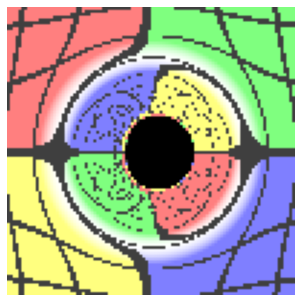

In [90]:
#read in deleted particle data
particle_arr = np.array([[[np.nan, np.nan, np.nan] for _ in range(num_pix_height)] for _ in range(num_pix_width)])
        
for os_file in os.listdir(os.fsencode(data_dir)):
    filename = os.fsdecode(os_file)

    basis_vectors = orthonormalize(camera_dir, camera_up)

    with open(data_dir + "/" + filename) as file:
        for line in file:
            linesplit = line.split()

            particle_id = int(linesplit[0])
            i = particle_id % num_pix_width
            j = particle_id // num_pix_width

            particle_arr[i][j] = assign_color(int(linesplit[7]), np.array([-float(linesplit[4]), -float(linesplit[5]), -float(linesplit[6])]), basis_vectors)

            if i != 0 and i != num_pix_width-1:
                continue
            if j != 0 and j != num_pix_height-1:
                continue

#find if any particles still exist in the simulation
num_alive_particles = 0
num_iterations = read_parameter_file(parfile, "Cactus")["cctk_itlast"]
for i in range(num_pix_width):
    for j in range(num_pix_height):
        if np.isnan(particle_arr[i][j][0]) or np.isnan(particle_arr[i][j][1]) or np.isnan(particle_arr[i][j][2]):
            num_alive_particles += 1
if num_alive_particles != 0:
    print("%d particles still exist in the simulation after %d iterations."%(num_alive_particles, num_iterations))

particle_arr = np.transpose(particle_arr, (1, 0, 2))

ax = plt.gca()
ax.imshow(particle_arr)
ax.axis("off")
ax.set_position([0, 0, 1, 1])
plt.savefig(image_dir + "/image.png")

In [91]:
reference_image = np.array([[[np.nan, np.nan, np.nan] for _ in range(num_pix_height)] for _ in range(num_pix_width)])

for pidx in range(num_pix_width*num_pix_height):
    i = pidx % num_pix_width
    j = pidx // num_pix_width 
    
    dir = get_new_dir(basis_vectors, h_fov, v_fov, i, j, num_pix_width, num_pix_height)
    reference_image[i][j] = assign_color(-1, get_new_dir(basis_vectors, h_fov, v_fov, i, j, num_pix_width, num_pix_height), basis_vectors)

reference_image = np.transpose(reference_image, (1, 0, 2))  

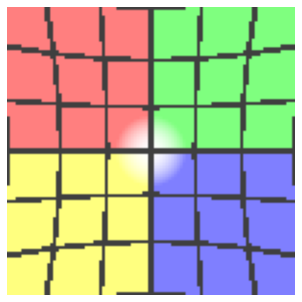

In [92]:
ax = plt.gca()
ax.imshow(reference_image)
ax.axis("off")
ax.set_position([0, 0, 1, 1])
plt.savefig(image_dir + "/reference_image.png")

<Figure size 576x576 with 0 Axes>

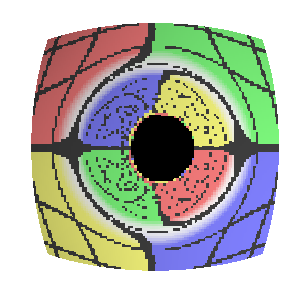

In [93]:
plt.figure(figsize=(8, 8))

theta = np.linspace(-h_fov/2, h_fov/2, num_pix_width+1)
phi = np.linspace(np.pi/2-v_fov/2, np.pi/2+v_fov/2, num_pix_height+1)
theta, phi = np.meshgrid(theta, phi)

color = np.zeros((np.shape(theta)[0]-1, np.shape(theta)[1]-1, 3))
for j in range(num_pix_height):
    for i in range(num_pix_width):
        color[i][j] = particle_arr[i][j]

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

X = np.cos(theta)*np.sin(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(phi)*np.cos(theta)
surf = ax.plot_surface(X, Y, Z, facecolors=color,
                       linewidth=0, antialiased=False, rstride=1, cstride=1)

ax.set_xlim(np.min(X)/1.5, np.max(X)/1.5)
ax.set_ylim(np.min(Y)/1.5, np.max(Y)/1.5)
ax.set_zlim(np.min(Z)/1.5, np.max(Z)/1.5)
ax.view_init(azim=0, elev=0)
ax.set_proj_type("ortho")
ax.set_box_aspect((1, 1, 1))
ax.axis("off")
ax.set_position([0, 0, 1, 1])
plt.savefig(image_dir + "/image_deprojected.png", format="png", dpi=300)

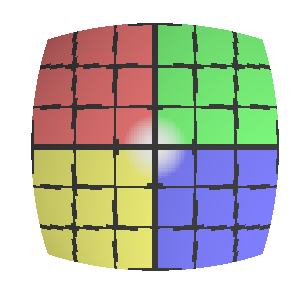

In [94]:
for j in range(num_pix_height):
    for i in range(num_pix_width):
        color[i][j] = reference_image[i][j]

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

X = np.cos(theta)*np.sin(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(phi)*np.cos(theta)
surf = ax.plot_surface(X, Y, Z, facecolors=color,
                       linewidth=0, antialiased=False, rstride=1, cstride=1)

#ax.set_xlim(np.min(X)/1.5, np.max(X)/1.5) projected along x-axis so this doesnt matter
ax.set_ylim(np.min(Y)/1.5, np.max(Y)/1.5)
ax.set_zlim(np.min(Z)/1.5, np.max(Z)/1.5)
ax.view_init(azim=0, elev=0)
ax.set_proj_type("ortho")
ax.set_box_aspect((1, 1, 1))
ax.axis("off")
ax.set_position([0, 0, 1, 1])
plt.savefig(image_dir + "/ref_image_deprojected.png", format="png", dpi=300)